In [ ]:
import glob
import pandas as pd
import os

path = '/content/drive/MyDrive/centaur/centaur_evaluation_sabrina/predictive_horizon_70B/*.csv'
all_files = glob.glob(path)
columns_to_load = ['participant_id', 'trial_num','is_free','log_likelihood_of_human_choice','choice','model_choice']

chunksize = 100_000  # adjust based on your RAM
li = []

for i, filename in enumerate(all_files, 1):
    print(f"Processing file {i}/{len(all_files)}: {os.path.basename(filename)}")
    for chunk in pd.read_csv(filename, chunksize=chunksize,usecols=columns_to_load):
        li.append(chunk)

horizon_70b = pd.concat(li, axis=0, ignore_index=True)

print("Loaded DataFrame:")
print(horizon_70b.info(memory_usage='deep'))

Processing file 1/6: participant_4.csv
Processing file 2/6: participant_6.csv
Processing file 3/6: participant_14.csv
Processing file 4/6: participant_22.csv
Processing file 5/6: participant_27.csv
Processing file 6/6: participant_31.csv
Loaded DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   participant_id                  14400 non-null  int64  
 1   trial_num                       14400 non-null  int64  
 2   is_free                         14400 non-null  bool   
 3   choice                          14400 non-null  object 
 4   model_choice                    6720 non-null   object 
 5   log_likelihood_of_human_choice  6720 non-null   float64
dtypes: bool(1), float64(1), int64(2), object(2)
memory usage: 1.7 MB
None


In [ ]:
horizon_70b_free=horizon_70b[horizon_70b['is_free']==True]

In [ ]:
free_trials=len(horizon_70b[horizon_70b['is_free']==True])

In [ ]:
free_trials

6720

In [ ]:
val_nll=-(horizon_70b['log_likelihood_of_human_choice'].sum())

In [ ]:
avg_nll=val_nll/free_trials

In [ ]:
avg_nll

np.float64(0.4835100097588674)

In [ ]:
import numpy as np

In [ ]:
def calculate_log_likelihood_stats(df):
    """
    Calculates the mean and standard error of the mean (SEM)
    for the 'log_likelihood_of_human_choice' column in a DataFrame.

    Args:
        df (pd.DataFrame): The input DataFrame containing a
                           'log_likelihood_of_human_choice' column.

    Returns:
        tuple: A tuple containing the mean log-likelihood and the SEM.
    """
    # Drop missing log-likelihoods (NaN)
    valid_ll = df["log_likelihood_of_human_choice"].dropna()

    # Compute mean and SEM
    if not valid_ll.empty:
        mean_ll = valid_ll.mean()
        sem_ll = valid_ll.std(ddof=1) / np.sqrt(len(valid_ll))
        return mean_ll, sem_ll
    else:
        return None, None

In [ ]:
# Example usage with the existing horizon_70b DataFrame
mean_ll_70b, sem_ll_70b = calculate_log_likelihood_stats(horizon_70b)

if mean_ll_70b is not None and sem_ll_70b is not None:
    print(f"Mean Log-Likelihood (horizon_70b): {mean_ll_70b:.4f}")
    print(f"SEM (horizon_70b): {sem_ll_70b:.4f}")
else:
    print("No valid log-likelihood data found in horizon_70b.")

Mean Log-Likelihood (horizon_70b): -0.4835
SEM (horizon_70b): 0.0061


In [ ]:
import glob
import os
import pandas as pd
import re

def normalize_filename(name):
    # Remove ' (1)', ' (2)', etc. before .csv
    return re.sub(r'\s\(\d+\)(?=\.csv$)', '', name)

path = '/content/drive/MyDrive/centaur/centaur_evaluation_sabrina/predictive_horizon_8B/*.csv'
all_files = glob.glob(path)

seen = set()
unique_files = []

for file in all_files:
    base_name = os.path.basename(file)
    normalized_name = normalize_filename(base_name)

    if normalized_name not in seen:
        seen.add(normalized_name)
        unique_files.append(file)

columns_to_load = ['participant_id', 'trial_num', 'is_free', 'log_likelihood_of_human_choice','choice','model_choice']
chunksize = 100_000
li = []

for i, filename in enumerate(unique_files, 1):
    print(f"Processing file {i}/{len(unique_files)}: {os.path.basename(filename)}")
    for chunk in pd.read_csv(filename, chunksize=chunksize, usecols=columns_to_load):
        li.append(chunk)

horizon_8b = pd.concat(li, axis=0, ignore_index=True)

print("Loaded DataFrame:")
print(horizon_8b.info(memory_usage='deep'))


Processing file 1/6: participant_4 (1).csv
Processing file 2/6: participant_22 (1).csv
Processing file 3/6: participant_27 (1).csv
Processing file 4/6: participant_31 (1).csv
Processing file 5/6: participant_14.csv
Processing file 6/6: participant_6.csv
Loaded DataFrame:
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 14400 entries, 0 to 14399
Data columns (total 6 columns):
 #   Column                          Non-Null Count  Dtype  
---  ------                          --------------  -----  
 0   participant_id                  14400 non-null  int64  
 1   trial_num                       14400 non-null  int64  
 2   is_free                         14400 non-null  bool   
 3   choice                          14400 non-null  object 
 4   model_choice                    6720 non-null   object 
 5   log_likelihood_of_human_choice  6720 non-null   float64
dtypes: bool(1), float64(1), int64(2), object(2)
memory usage: 1.7 MB
None


In [ ]:
horizon_8b_free=horizon_8b[horizon_8b['is_free']==True]

In [ ]:
# Example usage with the existing horizon_70b DataFrame
mean_ll_8b, sem_ll_8b = calculate_log_likelihood_stats(horizon_8b)

if mean_ll_8b is not None and sem_ll_8b is not None:
    print(f"Mean Log-Likelihood (horizon_8b): {mean_ll_8b:.4f}")
    print(f"SEM (horizon_70b): {sem_ll_8b:.4f}")
else:
    print("No valid log-likelihood data found in horizon_70b.")

Mean Log-Likelihood (horizon_8b): -0.4879
SEM (horizon_70b): 0.0058


In [ ]:
# prompt: load /content/drive/MyDrive/centaur/rw_model_metrics_horizon.json

import json

with open('/content/drive/MyDrive/centaur/rw_model_metrics_horizon.json', 'r') as f:
    metrics_data = json.load(f)


In [ ]:
# prompt: load /content/drive/MyDrive/centaur/rw_model_metrics_horizon.json

import json

with open('/content/drive/MyDrive/centaur/horizon/rw_model_metrics_simplified.json', 'r') as f:
    metrics_data_simplified = json.load(f)


In [ ]:
# prompt: extract average loss into mean_rw

# The negative log-likelihood is the loss.
# The average loss is the mean negative log-likelihood.
# The function calculate_log_likelihood_stats returns the mean log-likelihood.
# We need the negative of this mean for the average loss.
mean_rw = metrics_data.get('average_log_loss_per_trial', None)
mean_rw_simplified=metrics_data_simplified.get('average_log_loss_per_trial', None)

In [ ]:
sem_rw=mean_rw/np.sqrt(free_trials)
sem_rw_simplified=mean_rw_simplified/np.sqrt(free_trials)

In [ ]:
import os
def read_data_from_folder(folder_path):
    dfs = pd.DataFrame()
    file_count = 0  # counter for loaded files

    for filename in os.listdir(folder_path):
        if filename.endswith('.csv'):
            file_path = os.path.join(folder_path, filename)
            df = pd.read_csv(file_path)
            dfs = pd.concat([dfs, df], ignore_index=True)
            file_count += 1  # increment counter

    print(f"{file_count} CSV file(s) loaded.")
    return dfs


In [ ]:
llama_70b_horizon=read_data_from_folder('/content/drive/MyDrive/centaur/out/horizon/predictive/llama-70B/singles')

6 CSV file(s) loaded.


In [ ]:
llama_70b_horizon_free=llama_70b_horizon[llama_70b_horizon['is_free']==True]

In [ ]:
mean_ll_70b_llama,sem_ll_70b_llama=calculate_log_likelihood_stats(llama_70b_horizon)

In [ ]:
print(mean_ll_70b_llama)
print(sem_ll_70b_llama)

0.7410044242310895
0.011326358574294152


In [ ]:
llama_8b_horizon=read_data_from_folder('/content/drive/MyDrive/centaur/out/horizon/predictive/llama-8B/singles')

6 CSV file(s) loaded.


In [ ]:
llama_8b_horizon_free=llama_8b_horizon[llama_8b_horizon['is_free']==True]

In [ ]:
mean_ll_8b_llama,sem_ll_8b_llama=calculate_log_likelihood_stats(llama_8b_horizon)

In [ ]:
print(mean_ll_8b_llama)
print(sem_ll_8b_llama)

0.6940390654246411
0.0065021333647107575


In [ ]:
import matplotlib.pyplot as plt
import matplotlib.patches as patches
import numpy as np

In [ ]:
plt.rcParams.update({
    'font.size': 22,        # everything (titles, labels, ticks, legend) gets bigger
    'axes.titlesize': 30,   # override just titles if you want
    'axes.labelsize': 28,   # axis labels
    'xtick.labelsize': 26,  # x-tick labels
    'ytick.labelsize': 28,  # y-tick labels
    'legend.fontsize': 22 #  # legend text
})
def plot_loglikelihood_bars(mu_centaur, sd_centaur,
                             mu_centaurB, sd_centaurB,
                             mu_llama, sd_llama,
                             mu_llamaB, sd_llamaB,
                             mu_rw, sd_rw,
                             variant_labels = ['8B', '70B', '8B', '70B', 'RW'],
                             family_labels  = ['Centaur', 'LLama 3.1', 'Domain-Specific\nModel'],
                             colors = ['#E69F00', '#D55E00', '#56B4E9', '#0072B2', '#CC79A7'],
                             figsize=(12, 10)):
    """
    Clean and stylized grouped bar plot with NLL means and error bars.
    Includes two-level x-axis labels, grouped spacing, and a random guessing reference line.
    """
    # Values
    means = [-mu_centaur, -mu_centaurB, mu_llama, mu_llamaB, mu_rw]
    errs  = [sd_centaur, sd_centaurB, sd_llama, sd_llamaB, sd_rw]

    # Bar placement
    w = 0.50
    gap_in  = 0.00
    gap_out = 0.50
    xpos = np.array([
        0,
        0 + w + gap_in,                             # Centaur-70B
        0 + 2*w + gap_in + gap_out,                 # LLaMA-8B
        0 + 3*w + 2*gap_in + gap_out,               # LLaMA-70B
        0 + 4*w + 2*gap_in + 2*gap_out              # AU
    ])

    # Index groups for secondary x-axis labeling
    family_slices = [(0,1), (2,3), (4,4)]
    fig, ax = plt.subplots(figsize=figsize)

    # Bars
    bars=ax.bar(xpos, means, w,
           yerr=errs, capsize=5,
           color=colors, edgecolor='black', linewidth=0.3)
    for bar in bars:
      height = bar.get_height()
      ax.annotate(f'{height:.4f}',
                  xy=(bar.get_x() + bar.get_width() / 2, height),
                  xytext=(0, 3),
                  textcoords="offset points",
                  ha='center', va='bottom')


    # Chance line
    chance_nll = -np.log(0.5)
    ax.axhline(chance_nll, ls='--', c='grey', lw=1.2)
    ax.text(xpos[-2] + w*1.0, chance_nll, 'Random guessing',
            va='bottom', ha='left',fontsize=18)

    # X-axis: tick labels (1st tier)
    ax.set_xticks(xpos)
    ax.set_xticklabels(variant_labels, ha='center')

    # X-axis: group labels (2nd tier)
    for i, family_slice in enumerate(family_slices):
        if isinstance(family_slice, tuple):
            i0, i1 = family_slice
            center = (xpos[i0] + xpos[i1]) / 2
        else:
            center = xpos[family_slice]
        ax.text(center, -0.10, family_labels[i],
                ha='center', va='top',
                transform=ax.get_xaxis_transform(),
                fontsize=28
                )

    # Visual group dividers
    for i, family_slice in enumerate(family_slices[:-1]):
        if isinstance(family_slice, tuple):
            i0, i1 = family_slice
            ax.axvline(xpos[i1] + w/2 + gap_out/2, color='grey', lw=1)
        else:
            ax.axvline(xpos[family_slice] + w/2 + gap_out/2, color='grey', lw=1)

    # Axis labels and title
    ax.set_ylabel('Negative Log-Likelihood (NLL)')
    #ax.set_title('Predictive Performance')

    # Styling
    ax.spines[['top', 'right','left','bottom']].set_visible(True)
    ax.grid(False)
    ax.margins(x=0.04)
    # Hide all spines (top, bottom, left, right)
    for spine in ax.spines.values():
        spine.set_visible(True)

    # Get current axis limits (where bars are)
    x_min, x_max = ax.get_xlim()
    y_min, y_max = ax.get_ylim()

    plt.tight_layout()
    return fig


In [ ]:
colors = ['#44403B', '#E69F00', '#D55E00', '#56B4E9', '#0072B2','#CC79A7']

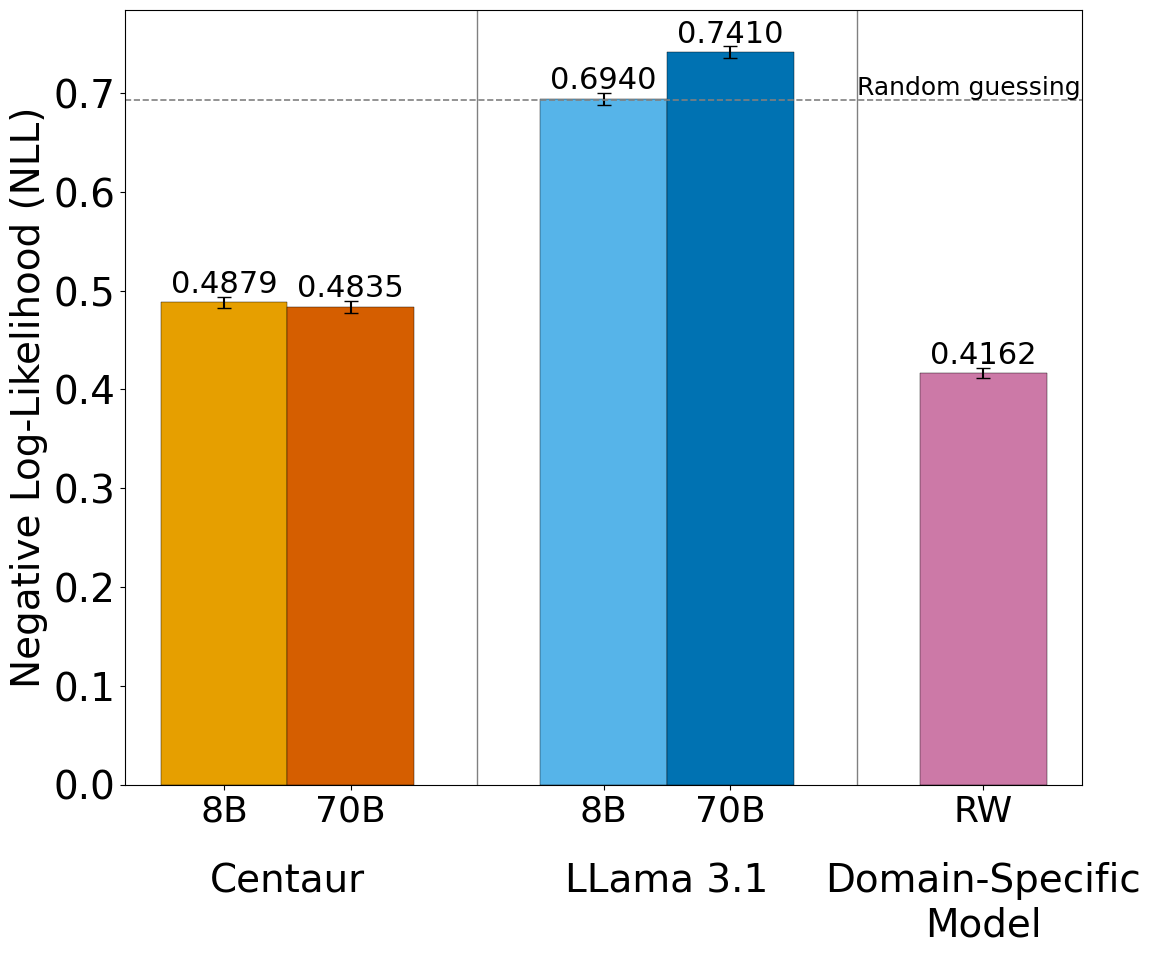

In [ ]:
nll_horizon=plot_loglikelihood_bars(
    mu_centaur=mean_ll_8b,mu_centaurB=mean_ll_70b,mu_llama=mean_ll_8b_llama,mu_llamaB=mean_ll_70b_llama,mu_rw=mean_rw_simplified,
    sd_centaur=sem_ll_8b,sd_centaurB=sem_ll_70b,sd_llama=sem_ll_8b,sd_llamaB=sem_ll_70b,sd_rw=sem_rw_simplified,
                        colors=colors[1:]
                                             )

In [ ]:
nll_horizon.savefig('/content/drive/MyDrive/centaur/figures/nll_horizon.png', format='png', dpi=600, edgecolor='white', bbox_inches='tight', pad_inches=0.1)

In [ ]:
# prompt: save mean_ll_70b and sem_ll_70b in centaur folder as json

# Ensure the directory exists
output_dir = '/content/drive/MyDrive/centaur/'
os.makedirs(output_dir, exist_ok=True)

# Create a dictionary with the values
stats_to_save = {
    'mean_ll_70b': mean_ll_70b,
    'sem_ll_70b': sem_ll_70b,
    'mean_ll_8b': mean_ll_8b,
    'sem_ll_8b': sem_ll_8b,
    'mean_rw': mean_rw
}

# Define the output filename
output_filename = os.path.join(output_dir, 'horizon_log_likelihood_stats.json')

# Save the dictionary to a JSON file
with open(output_filename, 'w') as f:
    json.dump(stats_to_save, f, indent=4)

print(f"Saved stats to {output_filename}")

Saved stats to /content/drive/MyDrive/centaur/horizon_log_likelihood_stats.json


In [ ]:
import pandas as pd
def calculate_agreement_percentage(df):
    """
    Calculates the percentage of rows where 'model_choice' equals 'human_choice'.

    Args:
        df (pd.DataFrame): The input DataFrame containing 'model_choice' and 'human_choice' columns.

    Returns:
        float: The percentage of agreement between model and human choices.
               Returns 0.0 if the DataFrame is empty or has no 'model_choice' or 'human_choice' columns.
    """
    if 'model_choice' not in df.columns or 'choice' not in df.columns or df.empty:
        return 0.0

    agreement_count = (df['model_choice'] == df['choice']).sum()
    print(agreement_count)
    total_rows = len(df)

    if total_rows == 0:
        return 0.0

    return (agreement_count / total_rows) * 100


In [ ]:
# Example usage with the existing horizon_8b_llama DataFrame
agreement_percentage_8b_centaur = calculate_agreement_percentage(horizon_8b_free)

print(f"Agreement Percentage (horizon_8b_centaur): {agreement_percentage_8b_centaur:.2f}%")


5297
Agreement Percentage (horizon_8b_centaur): 78.82%


In [ ]:
# Example usage with the existing horizon_8b_llama DataFrame
agreement_percentage_8b_llama = calculate_agreement_percentage(llama_8b_horizon_free)

print(f"Agreement Percentage (horizon_8b_llama): {agreement_percentage_8b_llama:.2f}%")


3698
Agreement Percentage (horizon_8b_llama): 55.03%


In [ ]:
# Example usage with the existing horizon_8b_llama DataFrame
agreement_percentage_70b_llama = calculate_agreement_percentage(llama_70b_horizon_free)

print(f"Agreement Percentage (horizon_70b_llama): {agreement_percentage_70b_llama:.2f}%")


4450
Agreement Percentage (horizon_70b_llama): 66.22%


In [ ]:
# Example usage with the existing horizon_8b_llama DataFrame
agreement_percentage_70b_centaur = calculate_agreement_percentage(horizon_70b_free)

print(f"Agreement Percentage (horizon_70b_centaur): {agreement_percentage_70b_centaur:.2f}%")


5274
Agreement Percentage (horizon_70b_centaur): 78.48%


In [ ]:
import seaborn as sns

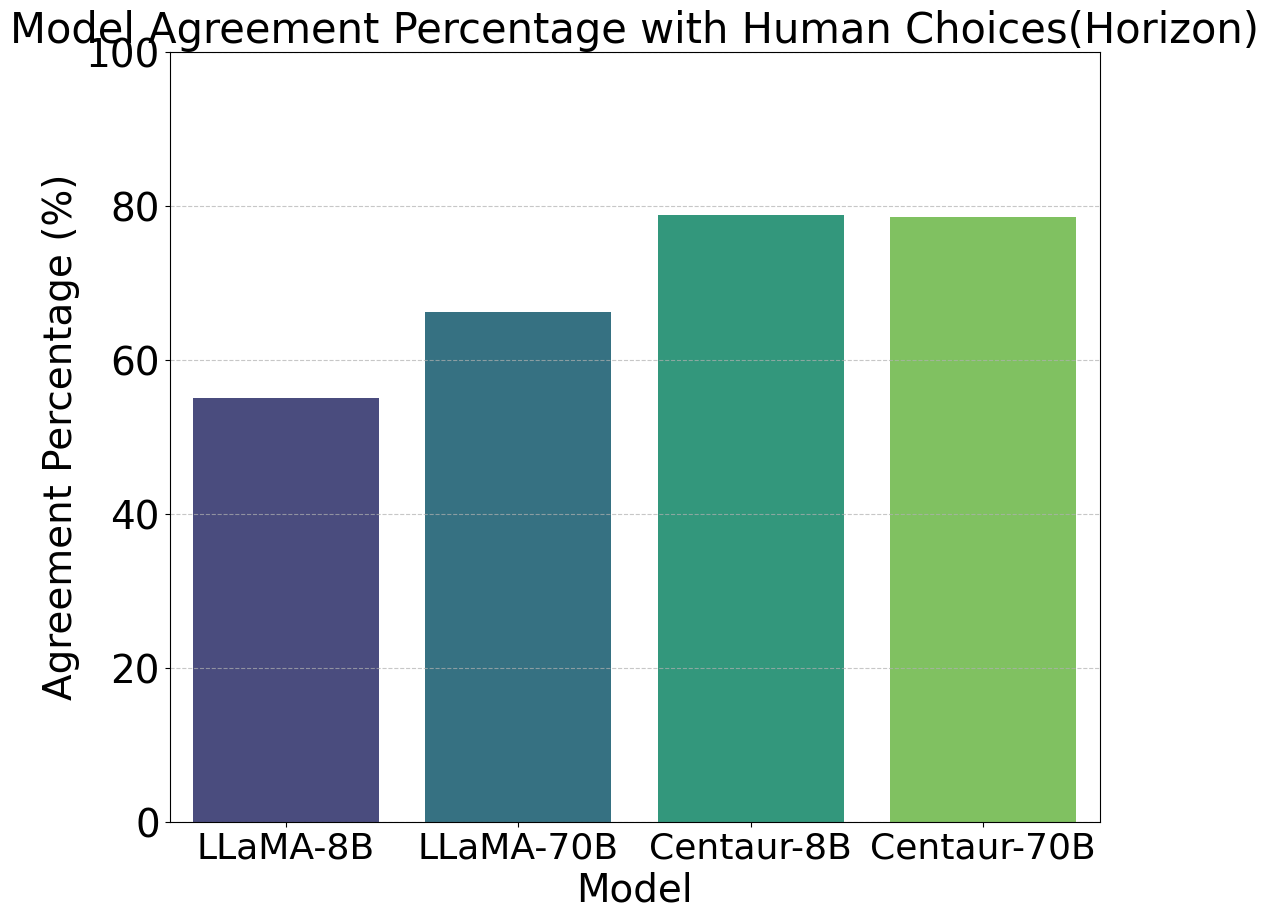

In [ ]:
# Create a dictionary to hold the agreement percentages
agreement_data = {
    'Model': ['LLaMA-8B', 'LLaMA-70B', 'Centaur-8B', 'Centaur-70B'],
    'Agreement Percentage': [
        agreement_percentage_8b_llama,
        agreement_percentage_70b_llama,
        agreement_percentage_8b_centaur,
        agreement_percentage_70b_centaur
    ]
}

# Create a pandas DataFrame from the data
agreement_df = pd.DataFrame(agreement_data)

# Create the bar plot
plt.figure(figsize=(12, 10))
sns.barplot(x='Model', y='Agreement Percentage', data=agreement_df, palette='viridis')
plt.title('Model Agreement Percentage with Human Choices(Horizon)')
plt.ylabel('Agreement Percentage (%)')
plt.xlabel('Model')
plt.ylim(0, 100) # Set y-axis limit to 0-100%
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.show()